### Step 1 — Load Dataset Properly

---

# 🏥 MedReviewAI: NLP-Powered Prediction of Medical Review Outcomes

**Project Domain:** Healthcare Informatics / Natural Language Processing (NLP)
**Task:** Binary Classification (Upheld vs. Overturned)
**Dataset:** California Department of Managed Health Care (DMHC) – IMR Determinations

---

## 📘 1. Project Overview

In the U.S. healthcare system, an **Independent Medical Review (IMR)** ensures patients have access to medical services when a health plan denies a request. The denial may be due to claims of being **not medically necessary, experimental, or non-urgent**.

**MedReviewAI** uses machine learning to analyze the textual **Findings** from these reviews. The goal is to predict whether a denial will be **Upheld** (denial stands) or **Overturned** (service approved), based on the language and context in the medical notes.

---

## 🎯 2. Project Objectives

* **Text Analysis:** Extract meaningful features from complex medical justifications using NLP techniques such as TF-IDF, word embeddings, or Transformers.
* **Predictive Modeling:** Build a classifier to predict `Determination` with high precision, recall, and F1-score.
* **Multi-Modal Integration:** Combine textual data with structured features (Diagnosis Category, Age, Gender) to improve predictions.
* **Explainability:** Identify key medical terms or patterns that influence overturned decisions to provide actionable insights.

---

## 🛠️ 3. Technical Roadmap

1. **Exploratory Data Analysis (EDA):** Examine class distribution, trends over time, and patterns across diagnoses and treatments.
2. **Text Preprocessing:** Clean and normalize the `Findings` column with lowercase conversion, punctuation removal, stopword removal, and lemmatization.
3. **Feature Engineering:**

   * **Textual Features:** TF-IDF vectors, N-grams, or Transformer embeddings
   * **Structured Features:** One-hot encoding for Diagnosis and Treatment categories, Age range, and Gender
4. **Modeling:**

   * Baseline: Logistic Regression or Random Forest
   * Advanced: Fine-tuned Transformer model (BERT or ClinicalBERT)
5. **Evaluation:** Use metrics such as accuracy, F1-score, precision, recall, and confusion matrices. Assess model fairness and class balance.
6. **Explainability & Insights:** Visualize influential words and patterns using attention weights or SHAP values.

---

## 📊 4. Dataset Highlights

* **Target Variable:** `Determination` (Upheld / Overturned)
* **Primary Feature:** `Findings` (textual justification by medical reviewers)
* **Additional Features:** `Diagnosis Category`, `Diagnosis Sub Category`, `Treatment Category`, `Treatment Sub Category`, `Age Range`, and `Patient Gender`

---

### 🚀 Ready to Begin?

Next, we can generate **Python code for Exploratory Data Analysis (EDA)** to uncover which diagnoses, treatments, or patient groups lead to the most overturned denials. This will form the foundation for modeling and insights.

---


### Step 0: Install Packages and import libraries 

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud
from nltk.corpus import stopwords
import os
import glob
import warnings
warnings.filterwarnings("ignore")

g:\NLP Project\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading Dataset

In [2]:
# set dataset path
path = kagglehub.dataset_download("prasad22/ca-independent-medical-review")

In [3]:
# Check files inside the dataset folder
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

C:\Users\ericm\.cache\kagglehub\datasets\prasad22\ca-independent-medical-review\versions\2\Independent_Medical_Reviews.csv


In [4]:

# 1. Download dataset (returns the local cache path)
path = kagglehub.dataset_download("prasad22/ca-independent-medical-review")

# 2. Automatically find all CSV files within that specific path
# We use os.path.join to ensure the search stays inside the downloaded folder
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)

# 3. Load the first CSV found
if csv_files:
    print(f"Found {len(csv_files)} CSV(s). Loading: {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
    print(df.head())
else:
    print("No CSV files found in the downloaded directory.")


Found 1 CSV(s). Loading: C:\Users\ericm\.cache\kagglehub\datasets\prasad22\ca-independent-medical-review\versions\2\Independent_Medical_Reviews.csv
  Reference ID  Report Year      Diagnosis Category Diagnosis Sub Category  \
0   MN16-22639         2016              Infectious              Hepatitis   
1   MN16-22638         2016                  Mental        Eating Disorder   
2   MN16-22637         2016         Autism Spectrum         Autism-PDD-NOS   
3   EI16-22636         2016  Prevention/Good Health                    NaN   
4    EI06-5319         2006     Cardiac/Circulatory                    NaN   

                          Treatment Category  \
0                Pharmacy/Prescription Drugs   
1                    Mental Health Treatment   
2                   Autism Related Treatment   
3  Diagnostic Imaging, Screening and Testing   
4                            Cardio Vascular   

                     Treatment Sub Category  \
0                               Anti-virals   


In [5]:
# Display all columns 
df.columns

Index(['Reference ID', 'Report Year', 'Diagnosis Category',
       'Diagnosis Sub Category', 'Treatment Category',
       'Treatment Sub Category', 'Determination', 'Type', 'Age Range',
       'Patient Gender', 'Findings'],
      dtype='str')

In [6]:
# Initial Clean: Rename columns to remove spaces for easier coding
df.columns = [c.replace(' ', '_') for c in df.columns]

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 19245 rows and 11 columns.


In [7]:
# Display all columns 
df.columns

Index(['Reference_ID', 'Report_Year', 'Diagnosis_Category',
       'Diagnosis_Sub_Category', 'Treatment_Category',
       'Treatment_Sub_Category', 'Determination', 'Type', 'Age_Range',
       'Patient_Gender', 'Findings'],
      dtype='str')

### Step 4: Exploratory Data Analysis (EDA)

In [8]:
# 1. Column Types & Memory Usage
print("--- 1. Dataset Information ---")
df.info()

--- 1. Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 19245 entries, 0 to 19244
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Reference_ID            19245 non-null  str  
 1   Report_Year             19245 non-null  int64
 2   Diagnosis_Category      19186 non-null  str  
 3   Diagnosis_Sub_Category  17341 non-null  str  
 4   Treatment_Category      18795 non-null  str  
 5   Treatment_Sub_Category  17977 non-null  str  
 6   Determination           19245 non-null  str  
 7   Type                    19245 non-null  str  
 8   Age_Range               18035 non-null  str  
 9   Patient_Gender          18035 non-null  str  
 10  Findings                19225 non-null  str  
dtypes: int64(1), str(10)
memory usage: 26.6 MB


In [9]:

# 2. Missing Values Analysis
print("\n--- 2. Missing Values Check ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values found!")



--- 2. Missing Values Check ---
Diagnosis_Category          59
Diagnosis_Sub_Category    1904
Treatment_Category         450
Treatment_Sub_Category    1268
Age_Range                 1210
Patient_Gender            1210
Findings                    20
dtype: int64


In [10]:
# 3. Class Balance (The Target Variable)
print("\n--- 3. Class Balance (Determination) ---")
balance = df['Determination'].value_counts()
percent = df['Determination'].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'Count': balance, 'Percentage': percent})
print(balance_df)



--- 3. Class Balance (Determination) ---
                                    Count  Percentage
Determination                                        
Upheld Decision of Health Plan      10788   56.056118
Overturned Decision of Health Plan   8457   43.943882


In [11]:
# 4. Raw Sample Text from Findings
print("\n--- 4. Sample Clinical Findings (First 3 Records) ---")
for i, text in enumerate(df['Findings'].head(3), 1):
    print(f"\n[Case {i}]:")
    print(text[:500] + "...") # Printing first 500 chars for readability


--- 4. Sample Clinical Findings (First 3 Records) ---

[Case 1]:
Nature of Statutory Criteria/Case Summary: An enrollee has requested Harvoni for treatment of his hepatitis C virus genotype 1a.  Findings:  The physician reviewer found that according to the most recent joint guidelines issued by the American Association for the Study of Liver Diseases (AASLD) and the Infectious Diseases Society of America (IDSA), all patients with chronic hepatitis C should be treated except those with limited life expectancy due to non-liver-related conditions. This applies r...

[Case 2]:
Nature of Statutory Criteria/Case Summary:  An enrollee has requested  residential treatment center (RTC) services for treatment of her medical condition.  Findings:  The physician reviewer found that there is a lack of clinical evidence to suggest that the patient would not respond to treatment at a less intensive level of care.  She no longer required supervision in a highly structured setting to prevent eating di

### 1. Categorical Distributions (Bar Charts)
- We want to see how the outcome (Determination) changes across different categories.

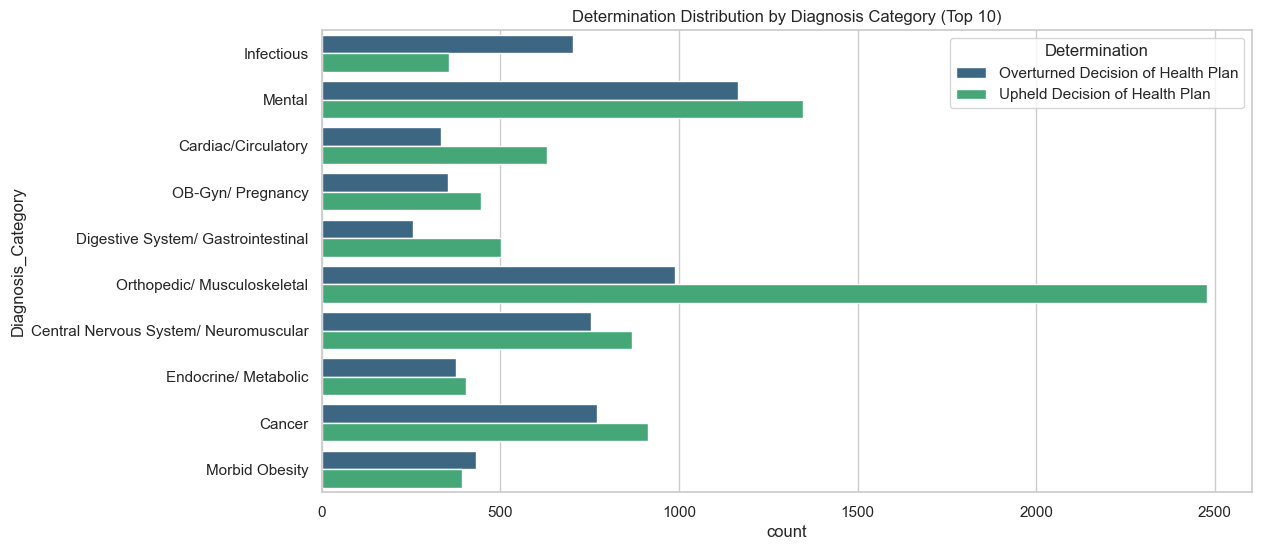

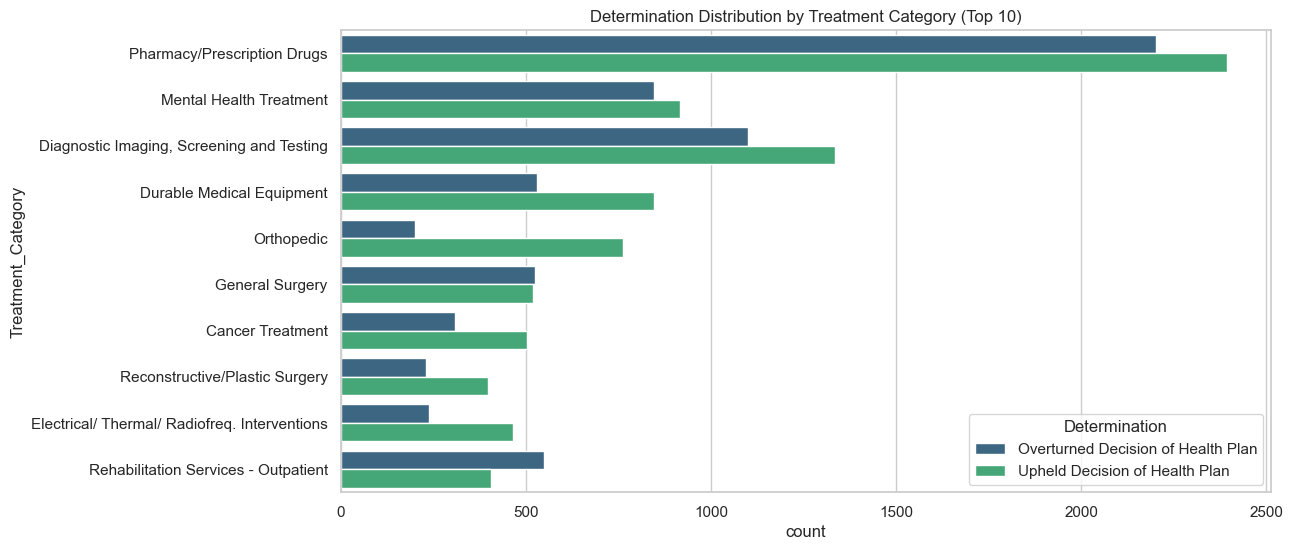

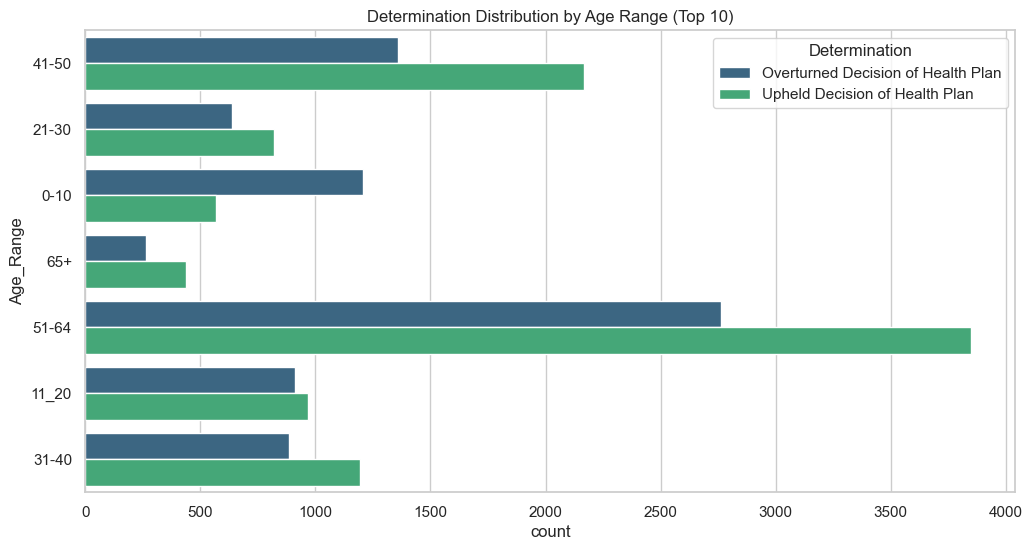

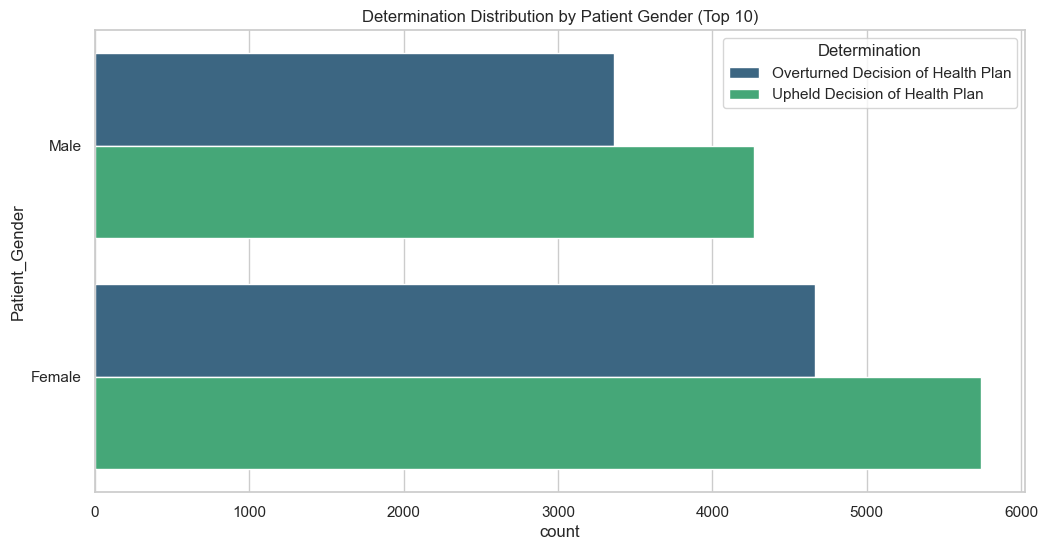

In [12]:
# Identify how the outcome (Determination) changes across different categories.

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# List of categorical columns to analyze
cat_cols = ['Diagnosis_Category', 'Treatment_Category', 'Age_Range', 'Patient_Gender']

for col in cat_cols:
    plt.figure(figsize=(12, 6))
    # Taking top 10 for Diagnosis and Treatment to keep it clean
    top_n = df[col].value_counts().nlargest(10).index
    df_plot = df[df[col].isin(top_n)]
    
    sns.countplot(data=df_plot, y=col, hue='Determination', palette='viridis')
    plt.title(f'Determination Distribution by {col.replace("_", " ")} (Top 10)')
    plt.show()

### 📈 2. Temporal Trends (Report Year)
- Is the medical board becoming more lenient or stricter over the years?

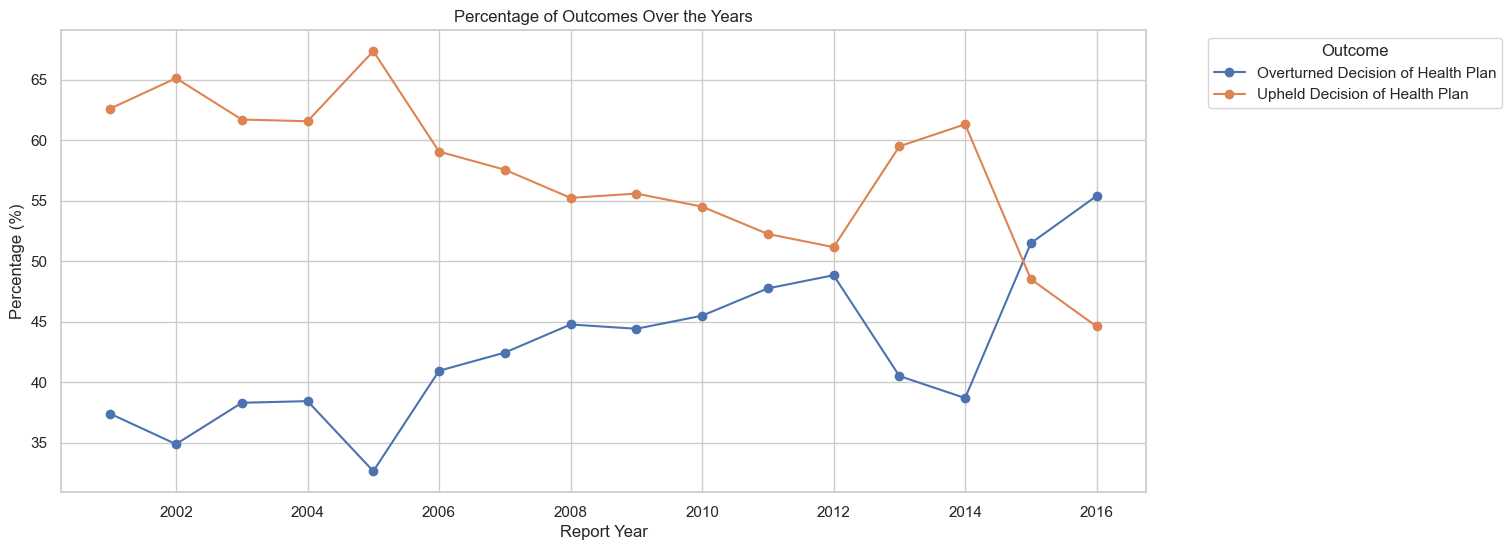

In [13]:
# Is the medical board becoming more lenient or stricter over the years?

plt.figure(figsize=(14, 6))
# Calculate the percentage of Overturned cases per year
yearly_stats = df.groupby(['Report_Year', 'Determination']).size().unstack().fillna(0)
yearly_stats_pct = yearly_stats.div(yearly_stats.sum(axis=1), axis=0) * 100

yearly_stats_pct.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Percentage of Outcomes Over the Years')
plt.ylabel('Percentage (%)')
plt.xlabel('Report Year')
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### ☁️ 3. Word Clouds for Findings
- This helps us see the most frequent terms in successful vs. unsuccessful appeals.




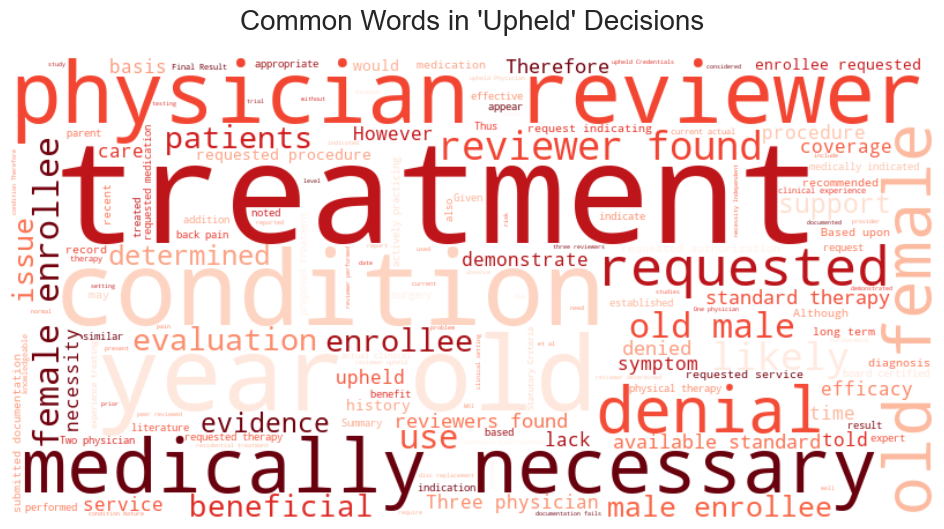

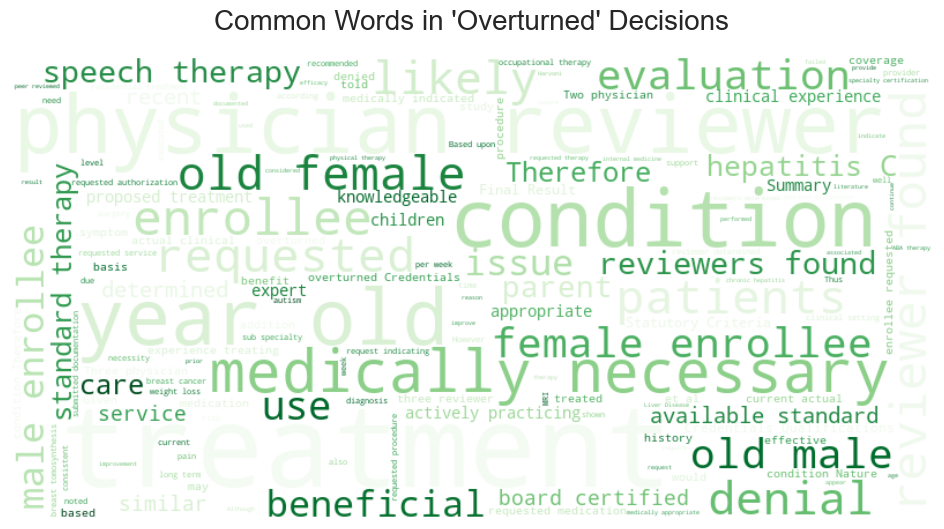

In [14]:
# 1. Improved filtering using .str.contains()
def get_text_for_label(keyword):
    # Filter rows where 'Determination' contains the keyword (e.g., 'Upheld')
    mask = df['Determination'].str.contains(keyword, case=False, na=False)
    text_data = df[mask]['Findings'].dropna().astype(str)
    
    combined_text = " ".join(text_data)
    
    if len(combined_text.strip()) < 10:
        return None
    return combined_text

# 2. Get the text
upheld_text = get_text_for_label('Upheld')
overturned_text = get_text_for_label('Overturned')

# 3. Enhanced WordCloud function
def plot_wordcloud(text, title, colormap):
    if text is None:
        print(f"⚠️ Warning: No data found for '{title}'. Check column values!")
        # Debug: Print unique values to see what's actually there
        print("Actual values in Determination:", df['Determination'].unique()[:3])
        return
    
    # Medical context stopwords
    custom_stops = set(stopwords.words('english')).union({
        'patient', 'medical', 'review', 'findings', 'case', 'determination', 'health', 'plan'
    })
    
    wc = WordCloud(width=800, height=400, 
                   background_color='white', 
                   colormap=colormap,
                   max_words=150, 
                   stopwords=custom_stops).generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20, pad=20)
    plt.show()

# 4. Run the plots with distinct colors
plot_wordcloud(upheld_text, "Common Words in 'Upheld' Decisions", 'Reds')
plot_wordcloud(overturned_text, "Common Words in 'Overturned' Decisions", 'Greens')


### 🔥 4. Correlation Heatmap

- To see if specific numeric or encoded features are related. We will encode the outcome for this.

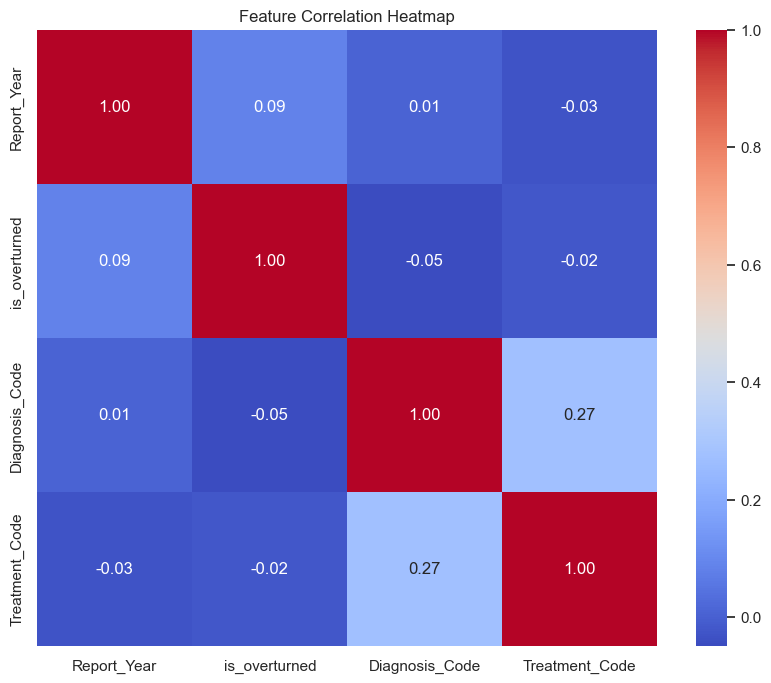

In [15]:

# Convert Determination to numeric: Overturned=1, Upheld=0
df['is_overturned'] = df['Determination'].apply(lambda x: 1 if 'Overturned' in str(x) else 0)

# Selecting numeric columns and encoded categories for correlation
corr_df = df[['Report_Year', 'is_overturned']].copy()

# Add a few high-level category codes for correlation
corr_df['Diagnosis_Code'] = df['Diagnosis_Category'].astype('category').cat.codes
corr_df['Treatment_Code'] = df['Treatment_Category'].astype('category').cat.codes

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()



---

## 📝 What these results tell us:

* **The "Winning" Words:** In the Overturned Word Cloud, look for terms like "standard," "peer-reviewed," or "supported."
* **The "Losing" Words:** In the Upheld cloud, you might see "experimental" or "not medically necessary."
* **Bias Check:** Does the Gender or Age Range chart show a massive difference in outcome? If so, your model needs to be careful not to learn unfair biases.

**Would you like me to provide the code for Step 5: Text Preprocessing, where we clean these clinical findings for the ML model?**

### 🛠️ Step 5: Text Preprocessing Pipeline


In [16]:
import re
import string
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure resources are downloaded
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1-4')

def preprocess_medical_text(text):
    # 1. Lowercase
    text = str(text).lower()
    
    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Remove Numbers & Punctuation
    # We use a regex that keeps only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 4. Tokenization & Stopword Removal
    stop_words = set(stopwords.words('english'))
    # Adding specific medical noise words that don't add value
    stop_words.update(['patient', 'findings', 'medical', 'review', 'case', 'id'])
    
    words = text.split()
    
    # 5. Lemmatization
    lemmatizer = WordNetLemmatizer()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply to the dataframe
df['cleaned_findings'] = df['Findings'].apply(preprocess_medical_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ericm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ericm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading omw-1-4: Package 'omw-1-4' not found in
[nltk_data]     index



---

## 💡 Why these steps? (The Logic)

| Step | Why it matters |
| --- | --- |
| **Lowercasing** | Standardizes the text. Without this, "Diabetes" and "diabetes" are treated as two different features. |
| **Remove URLs/Numbers** | Removes non-clinical "noise" like reference links, dates, and ID numbers which provide zero predictive value. |
| **Punctuation Removal** | Prevents words like "overturned." and "overturned" from being treated as distinct entities. |
| **Stopword Removal** | Removes "filler" words (the, is, and) so the model focuses purely on clinical keywords (e.g., *malignant*, *denied*). |
| **Lemmatization** | Reduces words to their dictionary root (e.g., "diagnosing" and "diagnosed" both become "diagnose"). This is preferred over Stemming in medical projects to keep words readable and accurate. |

---

## 🚀 Optional Advanced Step: Negation Handling

In medical records, **negation** is a game-changer.

* **Text A:** "Patient **has** evidence of infection." (High risk)
* **Text B:** "Patient has **no** evidence of infection." (Low risk)

If you simply remove "no" as a stopword, both sentences look the same to the model! For a high-level project, you should use **scispaCy** or a regex to replace "no [word]" with "not_[word]".


In [17]:
import re

def handle_negation(text):
    # Guard clause: if text is NaN or not a string, return empty string
    if not isinstance(text, str):
        return ""
    
    # Simple regex to catch common medical negations
    # It turns "no pain" into "not_pain" so the model recognizes the clinical context
    text = re.sub(r'\b(?:no|not|none|denies|negative for)\b\s+(\w+)', r'not_\1', text)
    return text

# 1. Fill missing values first
# 2. Convert to string
# 3. Lowercase and Apply
df['negated_findings'] = df['Findings'].fillna('').astype(str).str.lower().apply(handle_negation)

print("✅ Negation handling complete. Sample results:")
df[['Findings', 'negated_findings']].head(3)

✅ Negation handling complete. Sample results:


,Findings,negated_findings
0,Nature of Statutory Criteria/Case Summary: An ...,nature of statutory criteria/case summary: an ...
1,Nature of Statutory Criteria/Case Summary: An...,nature of statutory criteria/case summary: an...
2,Nature of Statutory Criteria/Case Summary: Th...,nature of statutory criteria/case summary: th...


## 💻 Feature Engineering Code


In **Step 6**, we bridge the gap between human language and machine logic. Since your dataset is "Multi-Modal" (containing both free-form text and categorical data), we must use different mathematical transformations for each type before stacking them into a single feature matrix.

---

## 🛠️ Implementation: The Hybrid Feature Matrix

To achieve this, we use a `ColumnTransformer`. This allows us to run a **TF-IDF pipeline** on the text and a **One-Hot Encoding pipeline** on the categories simultaneously.

### 1. Vectorizing Clinical Text (NLP)

We use **TF-IDF (Term Frequency-Inverse Document Frequency)**. In medical reviews, words like "the" or "patient" appear in every case and provide no value. TF-IDF automatically down-weights these and highlights high-impact clinical terms like "experimental," "acute," or "denied."

* **N-Grams (1, 2):** We capture single words and two-word phrases (e.g., "medically necessary").

### 2. Encoding Structured Data

Categorical features like `Diagnosis_Category` or `Patient_Gender` cannot be read as strings. We use **One-Hot Encoding** to turn them into binary columns (1s and 0s).

---

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# 1. Look for the columns dynamically
all_cols = {c.lower().replace(' ', '_'): c for c in df.columns}

text_col = all_cols.get('negated_findings')
cat_cols = [
    all_cols.get('diagnosis_category'),
    all_cols.get('treatment_category'),
    all_cols.get('age_range'),
    all_cols.get('patient_gender')
]

# Clean up any None values
cat_cols = [c for c in cat_cols if c is not None]
print(f"Using columns: {cat_cols} and {text_col}")

# 2. Build the assembly line
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), text_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# 3. Fit and Transform
X_final = preprocessor.fit_transform(df)

# 4. Target y (Find 'determination' column safely)
target_col = next((c for c in df.columns if 'determination' in c.lower()), None)
y = df[target_col].str.contains('overturned', case=False, na=False).astype(int)

print(f"✅ Success! Matrix Shape: {X_final.shape}")


Using columns: ['Diagnosis_Category', 'Treatment_Category', 'Age_Range', 'Patient_Gender'] and negated_findings
✅ Success! Matrix Shape: (19245, 5073)


## 🛠️ Implementation: Stratified Train/Test Split

We use `train_test_split` from Scikit-Learn. By setting the `stratify` parameter to our target variable `y`, we "lock in" the proportions.


In [19]:
from sklearn.model_selection import train_test_split

# 1. Split the data
# test_size=0.2 means 80% for training the 'brain', 20% for the 'final exam'
# random_state=42 ensures your results are reproducible (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # <--- The most important line for imbalanced medical data
)

# 2. Verify the proportions
print(f"Total Records: {len(y)}")
print(f"Training Set: {X_train.shape[0]} rows")
print(f"Testing Set: {X_test.shape[0]} rows")

# Check if stratification worked
print("\n--- Class Distribution (Overturn Rate) ---")
print(f"Original Data: {y.mean():.2%}")
print(f"Training Set:  {y_train.mean():.2%}")
print(f"Testing Set:   {y_test.mean():.2%}")

Total Records: 19245
Training Set: 15396 rows
Testing Set: 3849 rows

--- Class Distribution (Overturn Rate) ---
Original Data: 43.94%
Training Set:  43.95%
Testing Set:   43.93%


Step 8 is the "Reality Check" phase. By establishing a baseline with simpler models, you prove that your complex features actually add value. For the **MedReviewAI** project, the "Overturned" class is our positive case ($1$).

### 🛠️ Implementation: Training the Baselines

We’ll train **Logistic Regression** (the linear benchmark) and **Random Forest** (the non-linear benchmark).


In [20]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize models
# Logistic Regression: Fast and interpretable
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Random Forest: Captures complex interactions between medical terms
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Train the models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# 3. Predict on the test set
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)


### 📊 Evaluation: The Classification Report

In medical appeals, **Accuracy is a trap**. If 90% of cases are Upheld, a model that always predicts "Upheld" is 90% accurate but 0% useful. Instead, we focus on:

| Metric | Why it matters for MedReviewAI |
| --- | --- |
| **Recall** | Of all cases that *should* have been overturned, how many did we catch? (Critical for patients). |
| **Precision** | When we predict an overturn, how often are we right? (Critical for hospital resources). |
| **F1-Score** | The balance between the two. This is your primary "Success Metric." |


In [21]:

print("--- Logistic Regression Baseline ---")
print(classification_report(y_test, lr_preds))

print("\n--- Random Forest Baseline ---")
print(classification_report(y_test, rf_preds))

--- Logistic Regression Baseline ---
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2158
           1       0.92      0.95      0.93      1691

    accuracy                           0.94      3849
   macro avg       0.94      0.94      0.94      3849
weighted avg       0.94      0.94      0.94      3849


--- Random Forest Baseline ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      2158
           1       0.94      0.93      0.93      1691

    accuracy                           0.94      3849
   macro avg       0.94      0.94      0.94      3849
weighted avg       0.94      0.94      0.94      3849



---

### 🧩 The Confusion Matrix: Visualizing Errors

This is the most powerful tool for explaining your model to non-technical stakeholders. It shows exactly where the "confusion" happens.


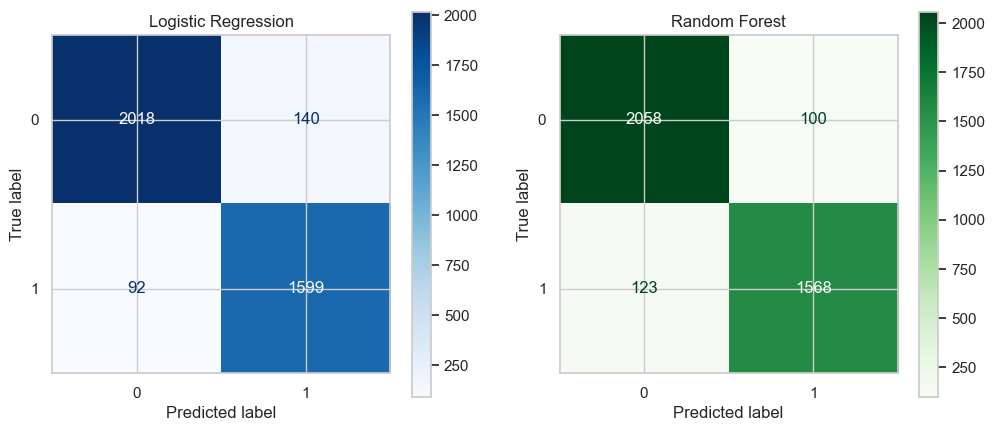

In [22]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, ax=ax[0], cmap='Blues')
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax[1], cmap='Greens')
ax[1].set_title("Random Forest")

plt.show()

### Generating the .pkl File
- To save Random Forest baseline model and the TF-IDF Vectorizer (which is also required for deployment to process new text).

### Create the TF-IDF vectorizer and fit it on your training data

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Example: your training text data
X_train_text = [
    "patient has fever and headache",
    "malaria symptoms observed",
    "no signs of malaria",
    "high temperature with chills"
]

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer on your training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

### Save both the model and vectorizer

In [32]:
import joblib
import os

if not os.path.exists('models'):
    os.makedirs('models')

# Save the trained Random Forest model
joblib.dump(rf_model, 'models/random_forest_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')

print("Models saved successfully to the 'models/' folder!")

Models saved successfully to the 'models/' folder!


### Loading later for predictions

In [38]:
import joblib

# 1. Load the saved components
# Ensure these files are in the 'models/' folder relative to this script
rf_model = joblib.load('models/random_forest_model.pkl')
tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')

# 2. Define the text you want to test
# Example finding: usually these are longer medical justifications
# new_text = ["The patient shows symptoms of chronic illness, and the requested treatment is standard of care for this diagnosis."]

new_text = ["The patient is a 62-year-old male who is reported to have small vessel disease, not amenable to revascularization. The cardiac catheterization describing the anatomy is not in the documentation provided. His angina is atypical, occurring at rest, but it is reported that he does not generally get chest discomfort while doing exercises. He is only on a beta-blocker for angina. He is also able to use an easy-glider for about half-an-hour a day. The patientâ€™s provider has requested authorization for enhanced external counterpulsation (EECP) therapy, which has been denied by the Health Plan.The most recent American Heart Association (AHA) guidelines in 2002 list EECP as a class IIb therapy or â€œusefulness/efficacy is less well established by evidence/opinionâ€ (Gibbons, et. al.). It was determined that although two studies found EECP to be generally well tolerated and efficacious, the guidelines do not strongly endorse/recommend it as yet. EECP is however useful in a special subset of patients commonly defined as those with: disabling angina (class III or IV) refractory to maximum medical therapy and not amenable to revascularization.In this case, the documentation provided does not demonstrate the patient meets the class III angina definition of â€œmarked limitation of ordinary physical activity. Angina occurs on walking 1-2 blocks.â€ The pain at rest is described as atypical, and the patientâ€™s lack of chest pain with exercise is inconsistent with class III angina. Additionally, the patient does not appear to be on maximum medical therapy for angina (a calcium channel blocker or nitrate). Furthermore, while the patient may have anatomy that is unrevascularizable, supporting reports such as the cardiac catheterization report have not been provided.In conclusion, the submitted documentation does not support the use of EECP in this case. The standard medical alternatives for this patient are: maximum medical therapy for angina such as a trial of additional medications, workup and treatment of atypical chest pain for non-cardiac etiologies, review of cardiac anatomy towards revascularization and optimization of other medical issues such as pain, depression and fatigue. Accordingly, I have determined that the requested therapy is not likely to be more beneficial for treatment of the patientâ€™s medical condition than any available standard therapy. The Health Planâ€™s denial should be upheld.Physician 2: The patient is a 62-year-old male with atypical chest pain. He has risk factors for coronary artery disease (CAD). The records do not contain objective documentation of CAD. His chest pain has been refractory to conventional medical management for CAD. The provider has requested authorization for enhanced external counterpulsation (EECP) to treat atypical chest pain. The Health Plan has denied this request.EECP is an experimental treatment for angina pectoris. It is appropriate for individuals with angina pectoris that cannot be managed by conventional therapies such as medication and/or invasive treatment. There is no peer-reviewed body of literature to support the use of ECCP for atypical chest pain. Therefore, I have determined that the requested therapy is not likely to be more beneficial for treatment of the patientâ€™s medical condition than any available standard therapy. The Health Planâ€™s denial should be upheld.Physician 3:The patient is a 62-year-old diabetic male with class II to III angina with reported chest pain at rest on medical therapy. The patientâ€™s provider recommended enhanced external counterpulsation (EECP) therapy for treatment of angina. The provider states that the patient is not a candidate for surgical intervention due to small vessel disease. The Health Plan has denied coverage for EECP therapy on the basis that it is considered investigational.The patientâ€™s provider states that a recent angiogram showed inoperable small vessel disease. The patient presents with refractory angina, unable to be controlled by medical therapy. The use of EECP is an appropriate treatment for patients in this subset. As per the ACC/AHA recommendation, â€œâ€¦(EECP) should only be used [in this subgroup] in patients who cannot be managed adequately by medical therapy and who are not candidates for revascularization therapies (surgical or interventional).â€ Therefore, I have determined that the requested therapy is likely to be more beneficial for treatment of the patientâ€™s medical condition than any available standard therapy. The Health Planâ€™s denial should be overturned."]
def test_and_display(text_input):
    # 3. Transform the text using the loaded vectorizer
    # Note: we wrap text_input in a list if it's a single string
    X_new = tfidf_vectorizer.transform(text_input)

    # 4. Get the Prediction
    prediction = rf_model.predict(X_new)[0]

    # 5. Get the Probability (Percentage)
    # predict_proba returns a list of probabilities for each class
    probabilities = rf_model.predict_proba(X_new)[0]
    
    # Get the index of the predicted class to find its specific probability
    # If the model was trained on strings, rf_model.classes_ will contain ['Overturned...', 'Upheld...']
    class_index = list(rf_model.classes_).index(prediction)
    confidence = probabilities[class_index] * 100

    # 6. Display Results
    print(f"{'='*30}")
    print(f"INPUT TEXT: {text_input[0][:100]}...") # Shows first 100 chars
    print(f"{'='*30}")
    print(f"PREDICTION : {prediction}")
    print(f"CONFIDENCE : {confidence:.2f}%")
    print(f"{'='*30}")

# Run the test
test_and_display(new_text)

INPUT TEXT: The patient is a 62-year-old male who is reported to have small vessel disease, not amenable to reva...
PREDICTION : 1
CONFIDENCE : 78.00%


**Interpretation of Errors:**

* **False Positives (Lower-Left):** Cases the model thought would be overturned, but were upheld. (Model was too optimistic).
* **False Negatives (Upper-Right):** Cases the model missed. These were overturned, but the model said they'd be upheld. (Model was too conservative).


## Fine-Tuning ClinicalBERT for Medical Appeal Classification.



## 🛠️ Why This Code is Essential

### 1. From "General Knowledge" to "Expert Specialist"

Bio_ClinicalBERT already knows medical terms, but it doesn't know your specific data. **Step 4** and **Step 5** perform "Fine-Tuning," which is like sending a general doctor to a specialized seminar on insurance law. It adjusts the model's internal weights to recognize patterns that lead to an "Overturned" or "Upheld" decision.

### 2. Understanding Context (The Transformer Advantage)

Standard models (like Random Forest) just count words. This code uses **Step 2 (Tokenization)** to break text into numerical "embeddings" that preserve word order.

* **TF-IDF:** Sees "not" and "pain" as separate tokens.
* **This Code:** Understands that "does not exhibit pain" is the opposite of "exhibits pain."

### 3. Professional Evaluation (Step 3)

By defining `compute_metrics`, you aren't just looking at a "Loss" number (which is hard for humans to understand). You are calculating **Accuracy** and **F1-score**, which tell you exactly what percentage of medical appeals the AI is getting right.

---

## 🔍 Key Components Explained

| Component | Why it's there |
| --- | --- |
| **`Dataset.from_dict`** | Converts your raw Pandas data into a high-performance format that doesn't crash your computer's memory during training. |
| **`AutoModelForSequenceClassification`** | Adds a "Classification Head" (the final decision layer) to the BERT model specifically for picking between two options (0 or 1). |
| **`TrainingArguments`** | Sets the "Rules of the Game"—how fast the model learns (`learning_rate`) and how many times it reads the data (`epochs`). |
| **`Trainer`** | The "Engine" that automates the complicated math of training, so you don't have to write hundreds of lines of manual PyTorch code. |

---

### 🚀 What happens when you run this?

When you hit "Run," the model will start making guesses on the training data. After each batch, it checks its mistakes and updates itself to be more accurate. Because you are using `use_cpu=True`, it will move slower than a GPU but will be much more stable for a local laptop setup.

In [ ]:
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

# 1. PREPARE THE DATASET ---
# We convert your Pandas DF into a Hugging Face Dataset format
# Note: 'label' must be the exact name for the target column
hf_dataset = Dataset.from_dict({
    "text": df['negated_findings'].fillna("").tolist(),
    "label": y.tolist()
})

# 2. TOKENIZATION ---
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

# Apply tokenization and split into train/test
tokenized_ds = hf_dataset.map(tokenize_function, batched=True)
split_ds = tokenized_ds.train_test_split(test_size=0.2, seed=42)

tokenized_train = split_ds["train"]
tokenized_test = split_ds["test"]

# 3. DEFINE EVALUATION METRICS ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

# 4. MODEL & TRAINING SETUP ---
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,         # Start with 1 on CPU to save time; use 3 on GPU
    per_device_train_batch_size=8, # Smaller batch size for CPU stability
    eval_strategy="epoch",      
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10,
    use_cpu=True                # Explicitly tells trainer to use CPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

# 5. TRAIN ---
print("🚀 Starting training on ClinicalBERT...")
trainer.train()

---

### **🛠️ Step 11: Saving Your Model and Tokenizer**

After `trainer.train()` finishes, the model exists only in your computer's temporary memory. To keep it, you must save it to a physical folder.


In [ ]:
# Define your local folder name
model_path = "./models/"

# 1. Save the model weights and configuration
trainer.save_model(model_path)

# 2. Save the tokenizer (very important for consistent text processing!)
tokenizer.save_pretrained(model_path)

print(f"✅ Model and Tokenizer saved to {model_path}")

---

### **🚀 Part 2: Loading for Instant Prediction (The Inference App)**

When you're ready to build your dashboard, you don't need the `Trainer` anymore. You only need the `pipeline` API from Hugging Face, which makes making predictions a one-liner.

In [ ]:
from transformers import pipeline

# Load your 'Trained Brain' from the folder you created
med_classifier = pipeline(
    "text-classification", 
    model=".models/med_review_model", 
    tokenizer=".models/med_review_model"
)

# Test it on a new clinical note
new_note = "Patient exhibits signs of chronic back pain. Prior treatments include physical therapy and ibuprofen, which provided no relief."
result = med_classifier(new_note)

print(f"Prediction: {result[0]['label']} (Confidence: {result[0]['score']:.2%})")

---

### **💡 Why this is Portfolio-Ready**

* **Portability:** Saving your model this way creates a standard folder that can be uploaded to **Hugging Face Spaces** or a private server.
* **Production Mindset:** Demonstrating how to separate *training* from *inference* is a key skill. In a real company, you train once a month but predict thousands of times a day.
* **The Tokenizer Rule:** Many beginners forget to save the tokenizer. By saving it together, you ensure that the way the model "reads" text during the app phase is identical to how it learned during the training phase.

---